**Importar librerías para el proyecto**


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

**Cargue de la BD**

In [ ]:
url = '/content/Relación entre las redes sociales y la salud mental_comas.csv'

**Lectura de archivo**

In [ ]:
MiAnalisis = pd.read_csv(url, delimiter=',')
MiAnalisis

,User_ID,Age,Gender,Daily_Screen_Time(hrs),Sleep_Quality(1-10),Stress_Level(1-10),Days_Without_Social_Media,Exercise_Frequency(week),Social_Media_Platform,Happiness_Index(1-10)
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0
...,...,...,...,...,...,...,...,...,...,...
495,U496,23,Male,6.9,5.0,7.0,4.0,2.0,X (Twitter),10.0
496,U497,43,Female,5.6,7.0,6.0,5.0,2.0,Facebook,9.0
497,U498,41,Male,7.7,5.0,7.0,2.0,2.0,LinkedIn,8.0
498,U499,23,Male,4.2,9.0,7.0,0.0,2.0,Facebook,9.0


**Limpieza de archivo**

In [ ]:
#Eliminar duplicados
MiAnalisis.duplicated().sum()
MiAnalisis = MiAnalisis.drop_duplicates()

#Eliminar y reemplazar caracteres
MiAnalisis.columns = (
    MiAnalisis.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_")
    .str.replace("[()]", "", regex=True)
    .str.replace("-", "_")
)
MiAnalisis

,user_id,age,gender,daily_screen_timehrs,sleep_quality1-10,stress_level1-10,days_without_social_media,exercise_frequencyweek,social_media_platform,happiness_index1-10
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0
...,...,...,...,...,...,...,...,...,...,...
495,U496,23,Male,6.9,5.0,7.0,4.0,2.0,X (Twitter),10.0
496,U497,43,Female,5.6,7.0,6.0,5.0,2.0,Facebook,9.0
497,U498,41,Male,7.7,5.0,7.0,2.0,2.0,LinkedIn,8.0
498,U499,23,Male,4.2,9.0,7.0,0.0,2.0,Facebook,9.0


In [ ]:
# Mi_Analisis = Mi_Analisis.rename(columns={'User_ID': 'ID',
#                                           'Age': 'Edad',
#                                           'Gender': 'Genero',
#                                           'Daily_Screen_Time(hrs)': 'Tiempo en pantalla(hrs)',
#                                           'Sleep_Quality(1-10)': 'Calidad del sueño(1-10)',
#                                           'Stress_Level(1-10)': 'Nivel de estres(1-10)',
#                                           'Days_Without_Social_Media': 'Dias sin redes sociales',
#                                           'Exercise_Frequency(week)': 'Frecuencia de ejercicio(semanal)',
#                                           'Social_Media_Platform': 'Plataforma digital',
#                                           'Happiness_Index(1-10)': 'Indice de felicidad/bienestar(1-10)'})
#Mi_Analisis['Genero'] = Mi_Analisis['Genero'].replace({'Male' : 'Masculino',
#                                                       'Female' : 'Femenino',
#                                                       'Other' : 'Otro'})

# Mi_Analisis

**Transformación de datos**

In [ ]:
ColumnasNumericas = MiAnalisis.select_dtypes(include='number')
ColumnasNumericas

,age,daily_screen_timehrs,sleep_quality1_10,stress_level1_10,days_without_social_media,exercise_frequencyweek,happiness_index1_10
0,44,3.1,7.0,6.0,2.0,5.0,10.0
1,30,5.1,7.0,8.0,5.0,3.0,10.0
2,23,7.4,6.0,7.0,1.0,3.0,6.0
3,36,5.7,7.0,8.0,1.0,1.0,8.0
4,34,7.0,4.0,7.0,5.0,1.0,8.0
...,...,...,...,...,...,...,...
495,23,6.9,5.0,7.0,4.0,2.0,10.0
496,43,5.6,7.0,6.0,5.0,2.0,9.0
497,41,7.7,5.0,7.0,2.0,2.0,8.0
498,23,4.2,9.0,7.0,0.0,2.0,9.0


**Objetivo**

Describir los patrones de uso de redes sociales en la muestra, considerando la edad, el género, el tiempo diario frente a la pantalla y la plataforma más utilizada

**Analisis Exploratorio**

In [ ]:
MiAnalisis.describe().round(2)

,age,daily_screen_timehrs,sleep_quality1_10,stress_level1_10,days_without_social_media,exercise_frequencyweek,happiness_index1_10
count,500.00,500.00,500.00,500.00,500.00,500.00,500.00
mean,32.99,5.53,6.30,6.62,3.13,2.45,8.38
std,9.96,1.73,1.53,1.54,1.86,1.43,1.52
min,16.00,1.00,2.00,2.00,0.00,0.00,4.00
25%,24.00,4.30,5.00,6.00,2.00,1.00,7.00
50%,34.00,5.60,6.00,7.00,3.00,2.00,9.00
75%,41.00,6.70,7.00,8.00,5.00,3.00,10.00
max,49.00,10.80,10.00,10.00,9.00,7.00,10.00


In [ ]:
(MiAnalisis.isnull().sum())
#Las columnas no necesitan modificarse ya que todos los datos siguen el mismo de formato entre minusculas y mayusculas

,0
user_id,0
age,0
gender,0
daily_screen_timehrs,0
sleep_quality1_10,0
stress_level1_10,0
days_without_social_media,0
exercise_frequencyweek,0
social_media_platform,0
happiness_index1_10,0


In [ ]:
MiAnalisis.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    500 non-null    object 
 1   age                        500 non-null    int64  
 2   gender                     500 non-null    object 
 3   daily_screen_timehrs       500 non-null    float64
 4   sleep_quality1_10          500 non-null    float64
 5   stress_level1_10           500 non-null    float64
 6   days_without_social_media  500 non-null    float64
 7   exercise_frequencyweek     500 non-null    float64
 8   social_media_platform      500 non-null    object 
 9   happiness_index1_10        500 non-null    float64
dtypes: float64(6), int64(1), object(3)
memory usage: 39.2+ KB


In [ ]:
MiAnalisis.head(10)
#MiAnalisis.head(50)
#MiAnalisis.head(100)
#MiAnalisis.head(250)

,user_id,age,gender,daily_screen_timehrs,sleep_quality1_10,stress_level1_10,days_without_social_media,exercise_frequencyweek,social_media_platform,happiness_index1_10
0,U001,44,Male,3.1,7.0,6.0,2.0,5.0,Facebook,10.0
1,U002,30,Other,5.1,7.0,8.0,5.0,3.0,LinkedIn,10.0
2,U003,23,Other,7.4,6.0,7.0,1.0,3.0,YouTube,6.0
3,U004,36,Female,5.7,7.0,8.0,1.0,1.0,TikTok,8.0
4,U005,34,Female,7.0,4.0,7.0,5.0,1.0,X (Twitter),8.0
5,U006,38,Male,6.6,5.0,7.0,4.0,3.0,LinkedIn,8.0
6,U007,26,Female,7.8,4.0,8.0,2.0,0.0,TikTok,7.0
7,U008,26,Female,7.4,5.0,6.0,1.0,4.0,Instagram,7.0
8,U009,39,Male,4.7,7.0,7.0,6.0,1.0,YouTube,9.0
9,U010,39,Female,6.6,6.0,8.0,0.0,2.0,Facebook,7.0


**Media**

**Promedio en edades**

In [ ]:
Edades = MiAnalisis['age'].mean().round(2)
print("El promedio en edad de hombres y mujeres es: ",Edades)
#El promedio de edad en general= 32.988

#El promedio de edad de las mujeres
Genero = MiAnalisis.groupby('gender')
Mujeres = Genero.get_group('Female')
AMujeres = Mujeres['age'].mean().round(2)
print("El promedio de edad de las mujeres:", AMujeres)

#El promedio de edad de los hombres
Hombres = Genero.get_group('Male')
AHombres = Hombres['age'].mean().round(2)
print("El promedio de edad de los hombres:", AHombres)

#El promedio de edad en otros generos
Otros = Genero.get_group('Other')
AOtros = Otros['age'].mean().round(2)
print("El promedio de edad de otros generos:", AOtros)

El promedio en edad de hombres y mujeres es:  32.99
El promedio de edad de las mujeres: 33.41
El promedio de edad de los hombres: 32.9
El promedio de edad de otros generos: 29.65


**Promedio tiempo en pantalla e indicadores de salud mental (estrés, calidad del sueño, índice de felicidad)**

In [ ]:
Nivel_Estres = MiAnalisis['stress_level1_10'].mean()
print('El promedio del nivel de estres en escala del 1 al 10 es:', Nivel_Estres)

Calidad_Sueño = MiAnalisis['sleep_quality1_10'].mean()
print('El promedio de la calidad del sueño en escala del 1 al 10 es:', Calidad_Sueño)

Indice_Felicidad = MiAnalisis['happiness_index1_10'].mean()
print('El promedio del indice de felicidad/bienestar en escala del 1 al 10 es:', Indice_Felicidad)

El promedio del nivel de estres en escala del 1 al 10 es: 6.618
El promedio de la calidad del sueño en escala del 1 al 10 es: 6.304
El promedio del indice de felicidad/bienestar en escala del 1 al 10 es: 8.376


**Promedio horas en pantalla**

In [ ]:
#El promedio de horas en las pantallas hombres, mujeres y otros

HorasHombres = Hombres['daily_screen_timehrs'].mean().round(2)
HorasMujeres = Mujeres['daily_screen_timehrs'].mean().round(2)
HorasOtros = Otros['daily_screen_timehrs'].mean().round(2)

print("Promedio de horas en las mujeres:", HorasMujeres)
print("Promedio de horas en los hombres:", HorasHombres)
print("Promedio de horas en otros generos:", HorasOtros)

Promedio de horas en las mujeres: 5.51
Promedio de horas en los hombres: 5.59
Promedio de horas en otros generos: 5.07


**Red Social mas usada**

In [ ]:
Red = MiAnalisis.groupby('social_media_platform')['user_id'].count()
Red
#Comparacion de redes sociales segun este muestra

,user_id
social_media_platform,
Facebook,81
Instagram,74
LinkedIn,87
TikTok,95
X (Twitter),88
YouTube,75


**Red social mas usada por sexo**

In [ ]:
RedM = MiAnalisis.groupby(['social_media_platform', 'gender']).size()
RedM

social_media_platform  gender
Facebook               Female    46
                       Male      34
                       Other      1
Instagram              Female    27
                       Male      44
                       Other      3
LinkedIn               Female    44
                       Male      39
                       Other      4
TikTok                 Female    44
                       Male      48
                       Other      3
X (Twitter)            Female    36
                       Male      46
                       Other      6
YouTube                Female    32
                       Male      37
                       Other      6
dtype: int64

**Red social que causa mayor estres**

In [ ]:
Datos_Facebook = MiAnalisis[MiAnalisis['social_media_platform'] == 'Facebook']
Promedio_Facebook = Datos_Facebook['stress_level1_10'].mean()
print('Promedio Facebook:', Promedio_Facebook)

Datos_LinkedIn = MiAnalisis[MiAnalisis['social_media_platform'] == 'LinkedIn']
Promedio_LinkedIn = Datos_LinkedIn['stress_level1_10'].mean()
print('Promedio LinkedIn:', Promedio_LinkedIn)

Datos_Youtube = MiAnalisis[MiAnalisis['social_media_platform'] == 'Youtube']
Promedio_Youtube = Datos_Youtube['stress_level1_10'].mean()
print('Promedio Youtube:', Promedio_Facebook)

Datos_TikTok = MiAnalisis[MiAnalisis['social_media_platform'] == 'TikTok']
Promedio_TikTok = Datos_TikTok['stress_level1_10'].mean()
print('Promedio TikTok:', Promedio_TikTok)

Datos_X = MiAnalisis[MiAnalisis['social_media_platform'] == 'X (Twitter)']
Promedio_X = Datos_X['stress_level1_10'].mean()
print('Promedio X (Twitter):', Promedio_X)

Datos_Instagram = MiAnalisis[MiAnalisis['social_media_platform'] == 'Instagram']
Promedio_Instagram = Datos_Instagram['stress_level1_10'].mean()
print('Promedio Instagram:', Promedio_Instagram)

Datos_Pantalla = MiAnalisis['daily_screen_timehrs'].mean()
print('Promedio tiempo pantalla:', Datos_Pantalla)

Promedio Facebook: 6.666666666666667
Promedio LinkedIn: 6.459770114942529
Promedio Youtube: 6.666666666666667
Promedio TikTok: 6.589473684210526
Promedio X (Twitter): 6.454545454545454
Promedio Instagram: 6.95945945945946
Promedio tiempo pantalla: 5.53


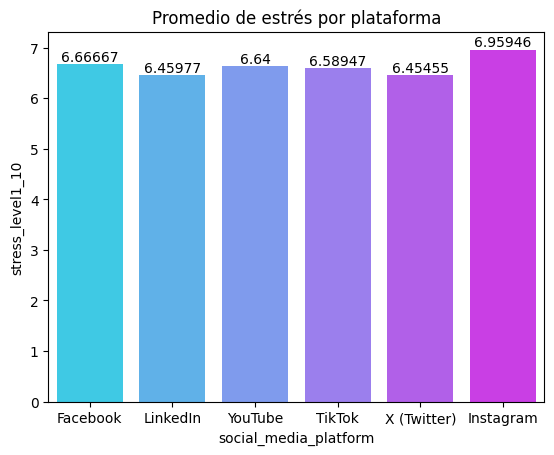

In [ ]:
Red_estres = MiAnalisis.groupby(['social_media_platform', 'stress_level1_10']).size()
Red_estres
ax = sns.barplot(MiAnalisis,
            x='social_media_platform',
            y='stress_level1_10',
            palette='cool',
            errorbar=None,
            legend=False,
            hue='social_media_platform')

for contenedor in ax.containers:
  ax.bar_label(contenedor)

plt.title('Promedio de estrés por plataforma')
plt.show()

**Según el gráfico:**

Instagram tiene el nivel más alto de estrés (~7).

Facebook, TikTok y YouTube presentan niveles intermedios (~6.5).

LinkedIn muestra niveles de estrés ligeramente menores (~6.3).

**Interpretación:**

Las plataformas más visuales y comparativas (como Instagram o TikTok) tienden a estar asociadas con mayor estrés y presión social.

En contraste, el uso de redes de contenido informativo o profesional (como LinkedIn o YouTube) se relaciona con niveles ligeramente menores de estrés, posiblemente por una menor exposición a contenido emocionalmente demandante.

**Mediana y moda**

In [ ]:
#Mediana de las edades
MedianaEdad = MiAnalisis['age'].median()
#Mediana de horas en pantalla
MedianaHorasPantalla = MiAnalisis['daily_screen_timehrs'].median()

#Moda de las edades
ModaEdad = MiAnalisis['age'].mode()
#Moda de horas en pantalla
ModaHorasPantalla = MiAnalisis['daily_screen_timehrs'].mode()



df_estadisticas = pd.DataFrame({
                                'Mediana': [MedianaEdad, MedianaHorasPantalla],
                                'Moda': [ModaEdad[0], ModaHorasPantalla[0]]},
                                index=['Edad', 'Horas_Pantalla'])
df_estadisticas

,Mediana,Moda
Edad,34.0,48.0
Horas_Pantalla,5.6,6.2


In [ ]:
#Mediana del nivel de estres
Mediana_Estres = MiAnalisis['stress_level1_10'].median()

#Mediana de la calidad del sueño
Mediana_Sueño = MiAnalisis['sleep_quality1_10'].median()

#Mediana del indice de felicidad/bienestar
Mediana_Felicidad = MiAnalisis['happiness_index1_10'].median()

#Moda del nivel de estres
Moda_Estres = MiAnalisis['stress_level1_10'].mode()

#Moda de la calidad del sueño
Moda_Sueño = MiAnalisis['sleep_quality1_10'].mode()

#Moda del indice de felicidad/bienestar
Moda_Felicidad = MiAnalisis['happiness_index1_10'].mode()

df_indicadores = pd.DataFrame({'Mediana': [Mediana_Estres, Mediana_Sueño, Mediana_Felicidad],
                               'Moda': [Moda_Estres[0], Moda_Sueño[0], Moda_Felicidad[0]]},
                                index=['Estres', 'Sueño', 'Felicidad'])
df_indicadores

,Mediana,Moda
Estres,7.0,7.0
Sueño,6.0,6.0
Felicidad,9.0,10.0


**STD**

In [ ]:
RedesSociales = MiAnalisis.groupby('social_media_platform')[ColumnasNumericas.columns]
std = RedesSociales.std().round(2)
std

,age,daily_screen_timehrs,sleep_quality1_10,stress_level1_10,days_without_social_media,exercise_frequencyweek,happiness_index1_10
social_media_platform,,,,,,,
Facebook,9.23,1.76,1.69,1.47,1.94,1.43,1.48
Instagram,10.06,1.63,1.50,1.51,1.76,1.50,1.57
LinkedIn,10.02,1.68,1.47,1.48,1.96,1.41,1.35
TikTok,9.89,1.75,1.44,1.67,1.74,1.37,1.63
X (Twitter),9.70,1.76,1.56,1.55,1.79,1.41,1.41
YouTube,10.54,1.73,1.46,1.54,1.92,1.40,1.68


**Sesgo**

In [ ]:
RedesSociales.skew().round(2)

,age,daily_screen_timehrs,sleep_quality1_10,stress_level1_10,days_without_social_media,exercise_frequencyweek,happiness_index1_10
social_media_platform,,,,,,,
Facebook,-0.24,-0.28,-0.03,-0.55,-0.17,0.50,-0.65
Instagram,-0.27,-0.08,0.44,0.02,0.40,0.21,-0.33
LinkedIn,-0.28,0.20,0.01,0.18,0.29,0.20,-0.76
TikTok,-0.13,0.05,-0.21,-0.24,0.22,0.16,-0.83
X (Twitter),0.27,0.22,-0.05,0.17,-0.24,0.42,-0.64
YouTube,-0.12,0.15,0.35,-0.12,0.01,0.03,-0.76


**Resumen exploratorio**

In [ ]:

Resumen = RedesSociales.agg([('Promedio','mean'),
                             ('Mediana','median'),
                             ('Moda', lambda x: x.mode()[0]),
                             ('Desviacion estandar','std'),
                             ('Cuartil1', lambda x: x.quantile(0.25)),
                             ('Cuartil2', lambda x: x.quantile(0.5)),
                             ('Cuartil3', lambda x: x.quantile(0.75)),
                             ('Sesgo','skew'),
                             ('Curtosis', lambda x: x.kurt())]) #std = desviación estandar
print(Resumen)
Resumen.to_excel('AnalisisExploratorioProyectoFinal.xlsx')

                             age                                            \
                        Promedio Mediana Moda Desviacion estandar Cuartil1   
social_media_platform                                                        
Facebook               33.728395    35.0   39            9.233109    27.00   
Instagram              34.297297    35.0   31           10.063810    26.00   
LinkedIn               34.402299    37.0   48           10.023762    25.50   
TikTok                 32.989474    34.0   27            9.893577    25.00   
X (Twitter)            30.193182    30.0   18            9.696377    21.75   
YouTube                32.533333    34.0   17           10.542492    23.00   

                                                             \
                      Cuartil2 Cuartil3     Sesgo  Curtosis   
social_media_platform                                         
Facebook                  35.0     42.0 -0.242014 -0.982546   
Instagram                 35.0     43.0 -0.27

**Analisis Correlacional**

**Covarianza**

In [ ]:
RedesSociales.cov().round(2)

age  daily_screen_timehrs  \
social_media_platform                                                           
Facebook              age                         85.25                 -1.59   
                      daily_screen_timehrs        -1.59                  3.11   
                      sleep_quality1_10            0.55                 -2.19   
                      stress_level1_10            -0.15                  2.07   
                      days_without_social_media   -2.07                 -0.39   
                      exercise_frequencyweek       0.36                 -0.21   
                      happiness_index1_10          0.16                 -1.84   
Instagram             age                        101.28                 -0.19   
                      daily_screen_timehrs        -0.19                  2.66   
                      sleep_quality1_10           -1.52                 -1.81   
                      stress_level1_10            -2.41                  1.71   
                      days_without_social_media    2.74                 -0.19   
                      exercise_frequencyweek       0.03                  0.20   
                      happiness_index1_10          1.98                 -1.88   
LinkedIn              age                        100.48                  2.46   
                      daily_screen_timehrs         2.46                  2.83   
                      sleep_quality1_10           -2.45                 -1.80   
                      stress_level1_10             2.78                  1.55   
                      days_without_social_media   -1.97                  0.21   
                      exercise_frequencyweek       2.93                 -0.62   
                      happiness_index1_10         -1.70                 -1.44   
TikTok                age                         97.88                  1.59   
                      daily_screen_timehrs         1.59                  3.08   
                      sleep_quality1_10           -0.61                 -1.89   
                      stress_level1_10            -1.11                  2.24   
                      days_without_social_media   -3.05                 -0.11   
                      exercise_frequencyweek      -0.14                 -0.23   
                      happiness_index1_10          0.43                 -2.04   
X (Twitter)           age                         94.02                  0.84   
                      daily_screen_timehrs         0.84                  3.11   
                      sleep_quality1_10            0.06                 -2.29   
                      stress_level1_10             1.38                  2.10   
                      days_without_social_media   -0.26                  0.12   
                      exercise_frequencyweek      -0.23                 -0.17   
                      happiness_index1_10          0.37                 -1.73   
YouTube               age                        111.14                 -2.42   
                      daily_screen_timehrs        -2.42                  3.01   
                      sleep_quality1_10           -0.52                 -1.90   
                      stress_level1_10             0.06                  2.03   
                      days_without_social_media    4.01                 -0.30   
                      exercise_frequencyweek       1.83                 -0.47   
                      happiness_index1_10          1.94                 -2.09   

                                                 sleep_quality1_10  \
social_media_platform                                                
Facebook              age                                     0.55   
                      daily_screen_timehrs                   -2.19   
                      sleep_quality1_10                       2.87   
                      stress_level1_10                       -1.67   
                      days_without_social_media               0.11 

**Coeficiente de correlación de Pearson**

In [ ]:
Pearson = RedesSociales.corr(method='pearson').round(2)
print(Pearson)

                                                  age  daily_screen_timehrs  \
social_media_platform                                                         
Facebook              age                        1.00                 -0.10   
                      daily_screen_timehrs      -0.10                  1.00   
                      sleep_quality1_10          0.04                 -0.73   
                      stress_level1_10          -0.01                  0.79   
                      days_without_social_media -0.12                 -0.11   
                      exercise_frequencyweek     0.03                 -0.09   
                      happiness_index1_10        0.01                 -0.71   
Instagram             age                        1.00                 -0.01   
                      daily_screen_timehrs      -0.01                  1.00   
                      sleep_quality1_10         -0.10                 -0.74   
                      stress_level1_10          -0.1

**Graficos**

**Pairplot**

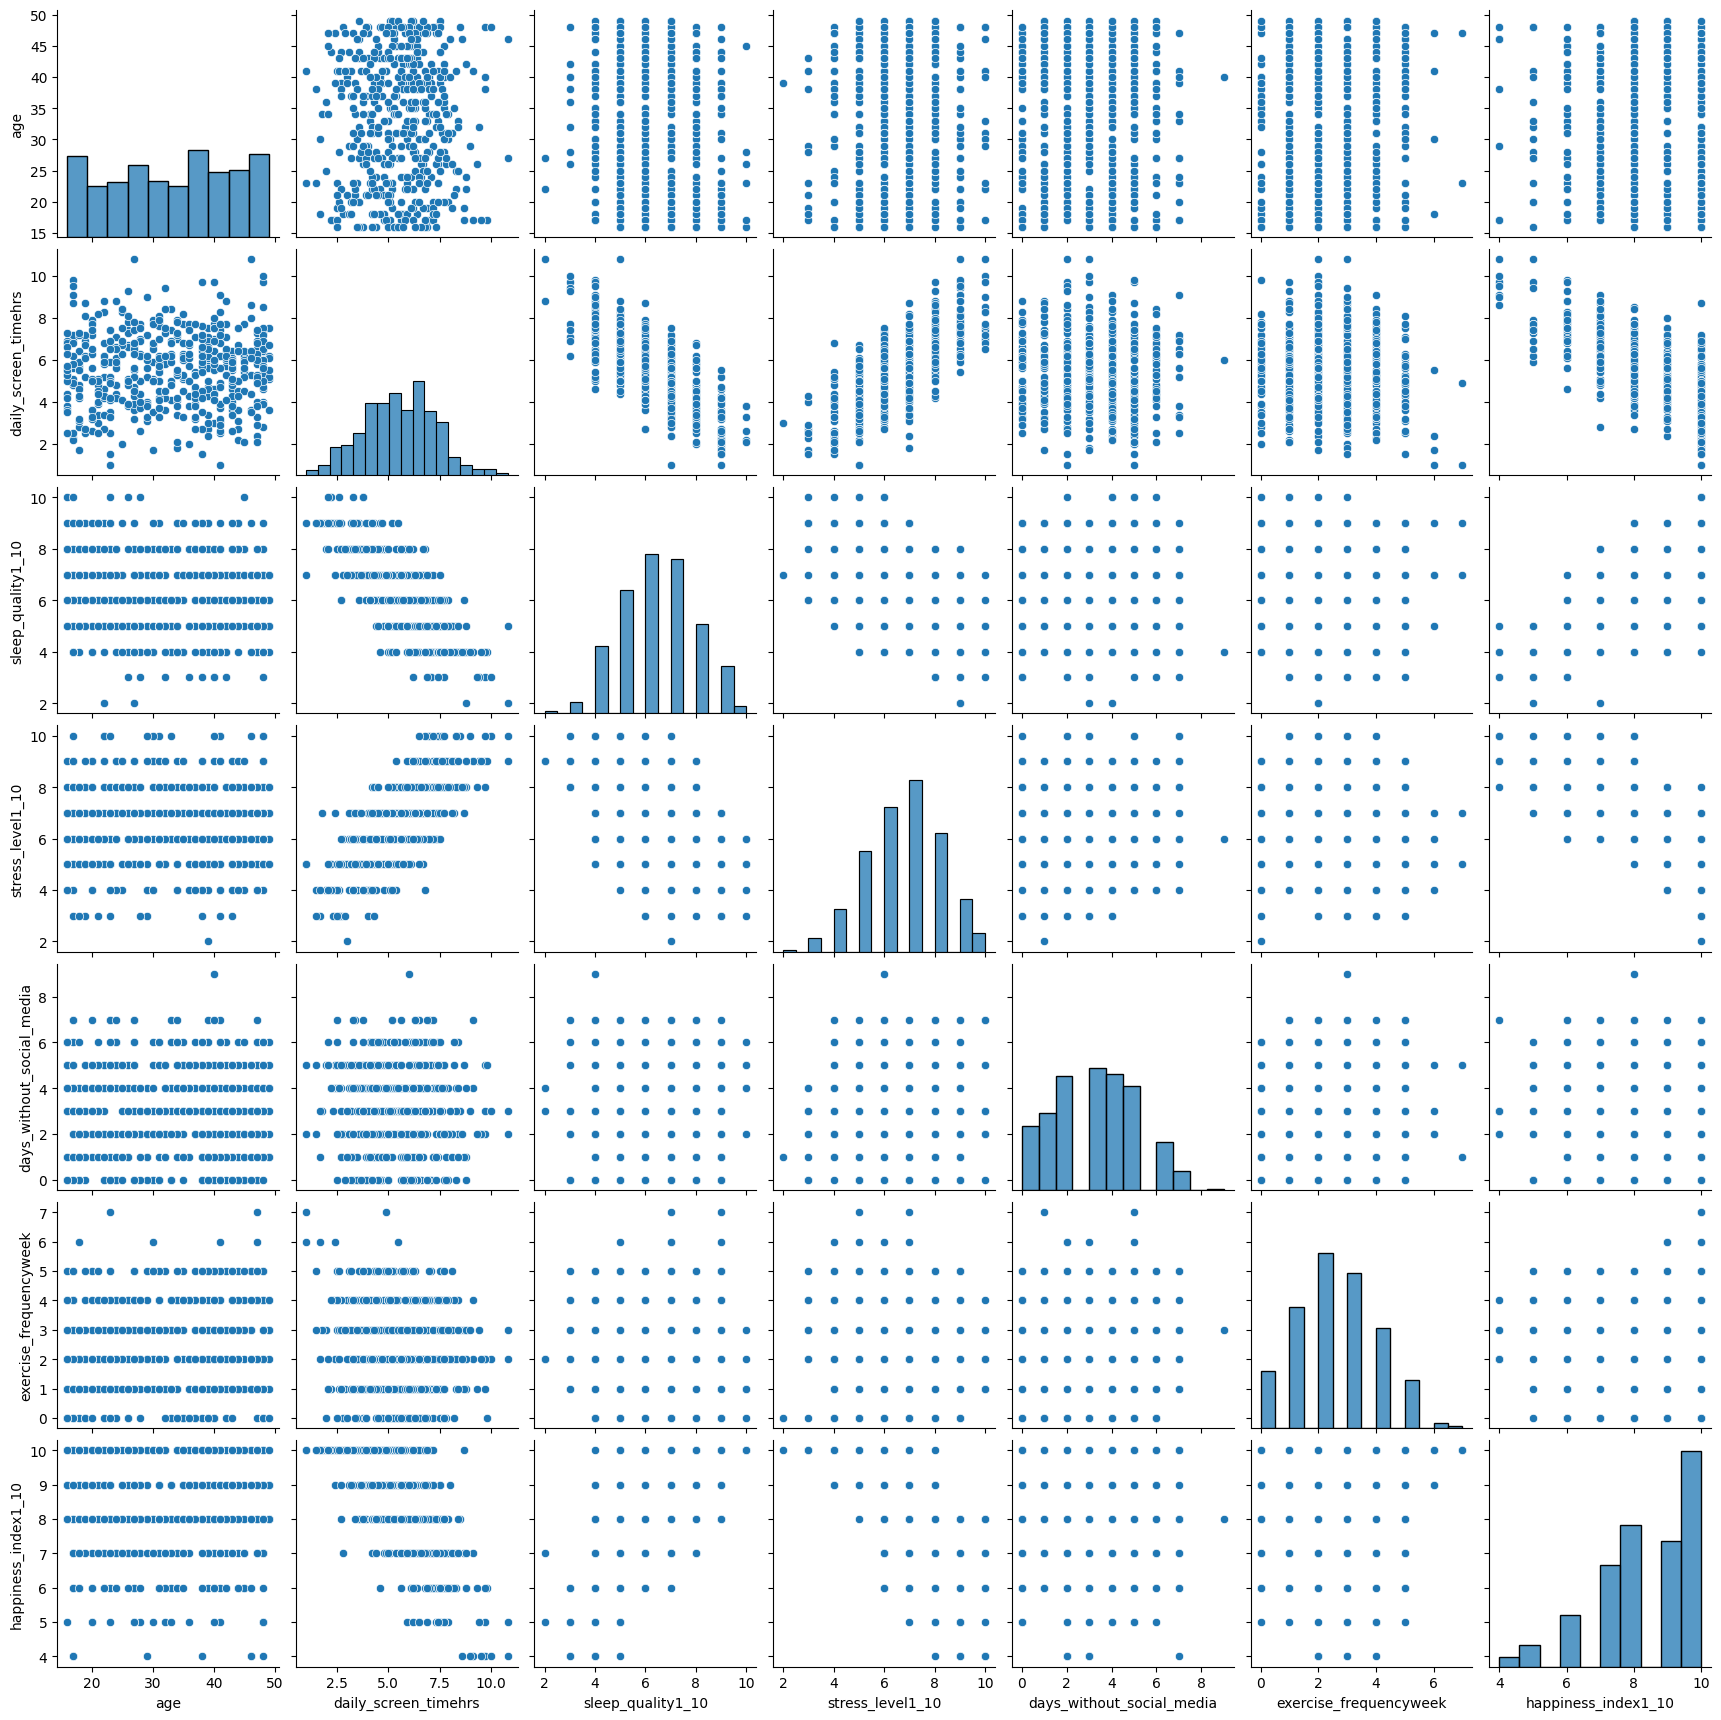

In [ ]:
sns.pairplot(MiAnalisis)
plt.show()

El análisis visual evidencia relaciones entre las principales variables del estudio, destacando una tendencia inversa entre las horas diarias frente a la pantalla y los indicadores de bienestar (felicidad y calidad del sueño). A mayor exposición a redes sociales, se observan valores más altos de estrés y menor calidad del descanso.

**Pairplot por redes**

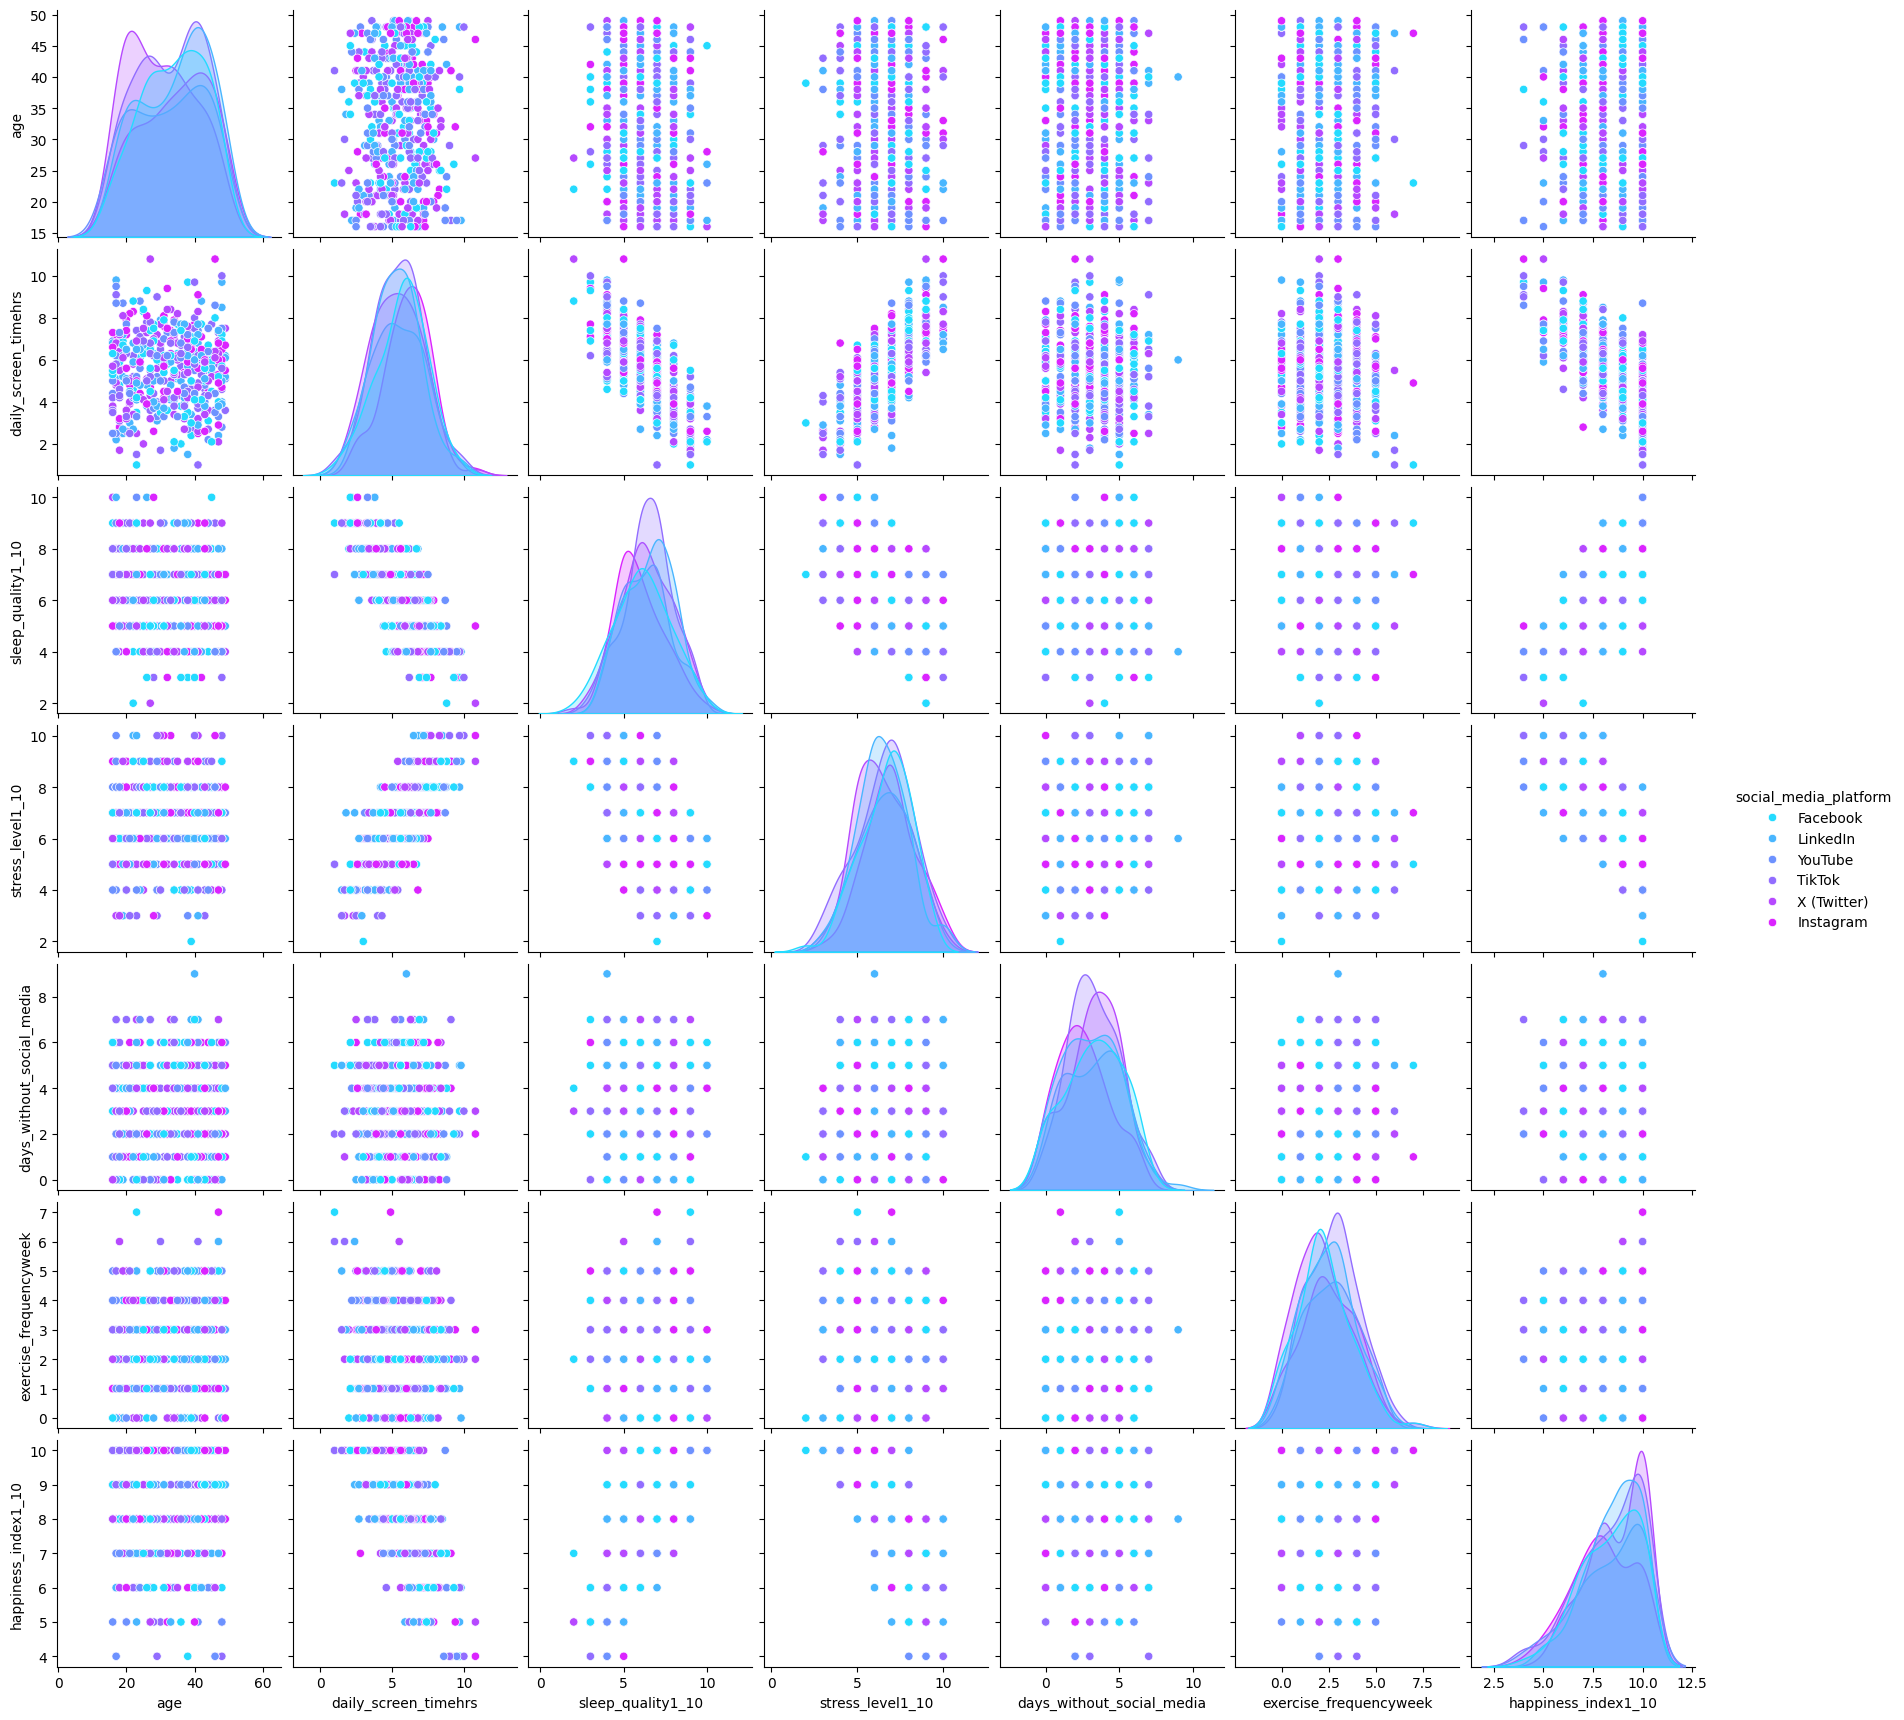

In [ ]:
sns.pairplot(MiAnalisis,
             hue='social_media_platform',
             palette= 'cool')
plt.show()

Al segmentar por plataforma, se aprecian diferencias notables en los patrones de comportamiento. Redes como Instagram y TikTok tienden a concentrar usuarios con mayor tiempo de uso y niveles más altos de estrés, mientras que otras como Facebook o X (Twitter) muestran una distribución más equilibrada. Esto sugiere que la naturaleza del contenido y la dinámica de cada red influyen en el bienestar de los usuarios.

**Histograma**

**Histograma de redes sociales en base el tiempo en pantalla**

/tmp/ipython-input-3118097095.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=MiAnalisis, x='social_media_platform', weights='daily_screen_timehrs', multiple='stack', palette='magma')


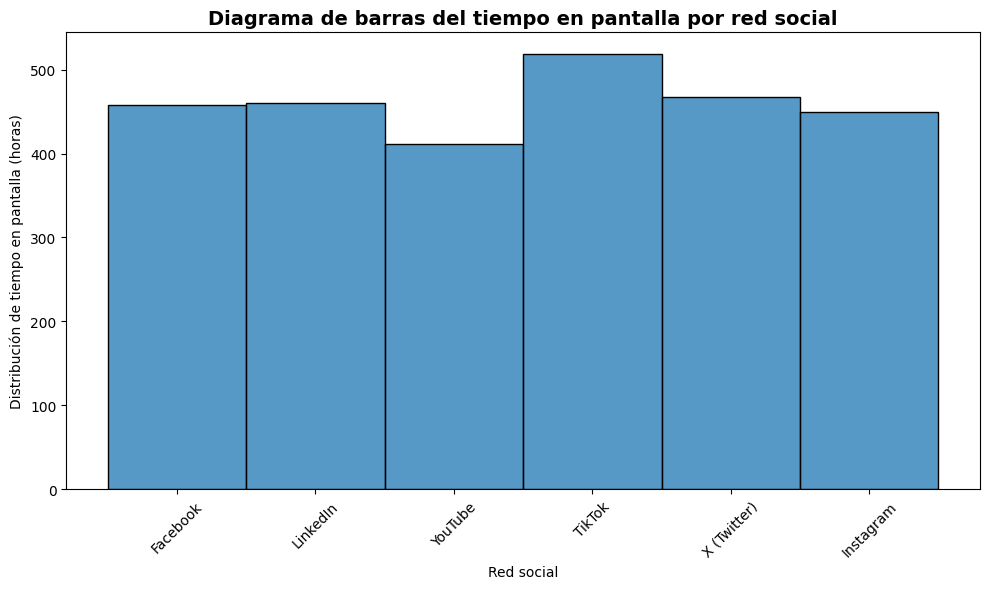

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=MiAnalisis, x='social_media_platform', weights='daily_screen_timehrs', multiple='stack', palette='magma')
plt.title("Diagrama de barras del tiempo en pantalla por red social", fontsize=14, fontweight='bold')
plt.xlabel("Red social")
plt.ylabel("Distribución de tiempo en pantalla (horas)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La mayoría de los usuarios pasa entre 3 y 5 horas diarias en redes sociales. Este rango representa un uso moderado a alto que podría tener efectos acumulativos en la salud mental y el descanso. Los valores extremos (más de 6 horas) corresponden a un grupo reducido, pero potencialmente más afectado por estrés o fatiga digital.

Correlación Tiempo en pantalla vs Calidad del sueño: -0.76


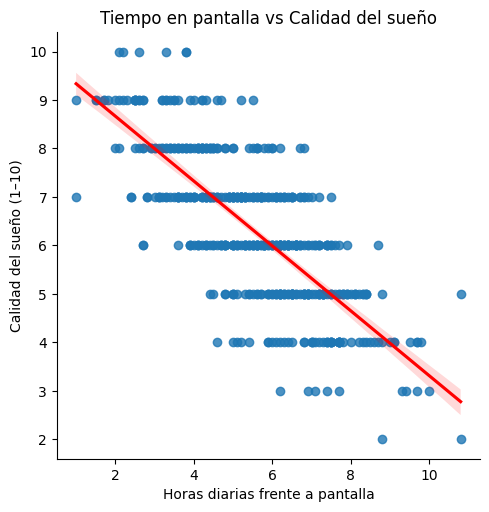

In [ ]:
Tiempo_Sueño = MiAnalisis['daily_screen_timehrs'].corr(MiAnalisis['sleep_quality1_10'])
print(f'Correlación Tiempo en pantalla vs Calidad del sueño: {Tiempo_Sueño:.2f}')

sns.lmplot(x='daily_screen_timehrs',
           y='sleep_quality1_10',
           data=MiAnalisis,
           line_kws={'color': 'red'})

plt.title('Tiempo en pantalla vs Calidad del sueño')
plt.xlabel('Horas diarias frente a pantalla')
plt.ylabel('Calidad del sueño (1–10)')
plt.show()

Tendencia negativa (pendiente descendente). Fuerte correlación negativa: más tiempo frente a pantalla se asocia con peor calidad del sueño.

Correlación Tiempo en pantalla vs Nivel de estres: 0.74


<Figure size 800x800 with 0 Axes>

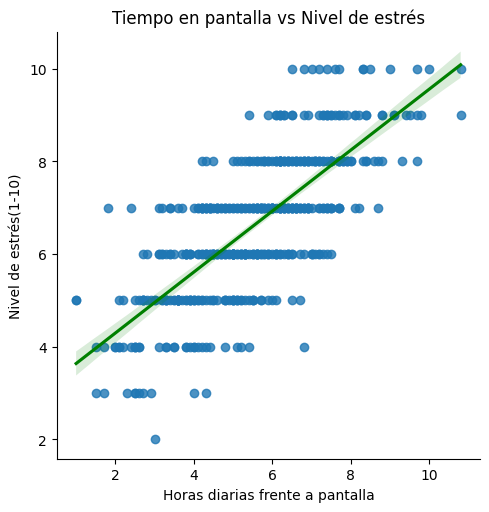

In [ ]:
plt.figure(figsize=(8, 8))
Tiempo_Estres = MiAnalisis['daily_screen_timehrs'].corr(MiAnalisis['stress_level1_10'])
print(f'Correlación Tiempo en pantalla vs Nivel de estres: {Tiempo_Estres:.2f}')

sns.lmplot(x='daily_screen_timehrs',
           y='stress_level1_10',
           data=MiAnalisis,
           line_kws={'color': 'green'})

plt.title('Tiempo en pantalla vs Nivel de estrés')
plt.xlabel('Horas diarias frente a pantalla')
plt.ylabel('Nivel de estrés(1-10)')
plt.show()

Tendencia positiva (más horas = más estrés). Fuerte correlación positiva: mayor tiempo de pantalla implica más estrés.

Correlación Tiempo en pantalla vs Felicidad/bienestar: -0.71


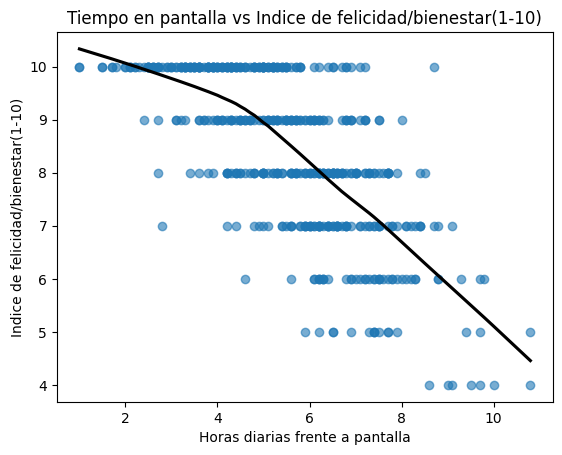

In [ ]:
Tiempo_Felicidad = MiAnalisis['daily_screen_timehrs'].corr(MiAnalisis['happiness_index1_10'])
print(f'Correlación Tiempo en pantalla vs Felicidad/bienestar: {Tiempo_Felicidad:.2f}')

sns.regplot(x='daily_screen_timehrs',
           y='happiness_index1_10',
           data=MiAnalisis,
           lowess=True,
           line_kws={'color': 'black'},
           scatter_kws={'alpha':0.6})

plt.title('Tiempo en pantalla vs Indice de felicidad/bienestar(1-10)')
plt.xlabel('Horas diarias frente a pantalla')
plt.ylabel('Indice de felicidad/bienestar(1-10)')
plt.show()

Relación no lineal (curva en U invertida). La felicidad y/o el bienestar aumentan ligeramente con uso moderado (3-4 horas), pero disminuyen con uso excesivo. Uso moderado, mayor felicidad. Fuerte correlación negativa: el exceso de tiempo frente a pantallas reduce la felicidad percibida.

**Histograma de las redes en base la edad**

/tmp/ipython-input-3434121659.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(data=MiAnalisis, x='social_media_platform', weights='age', multiple='stack', palette='viridis')


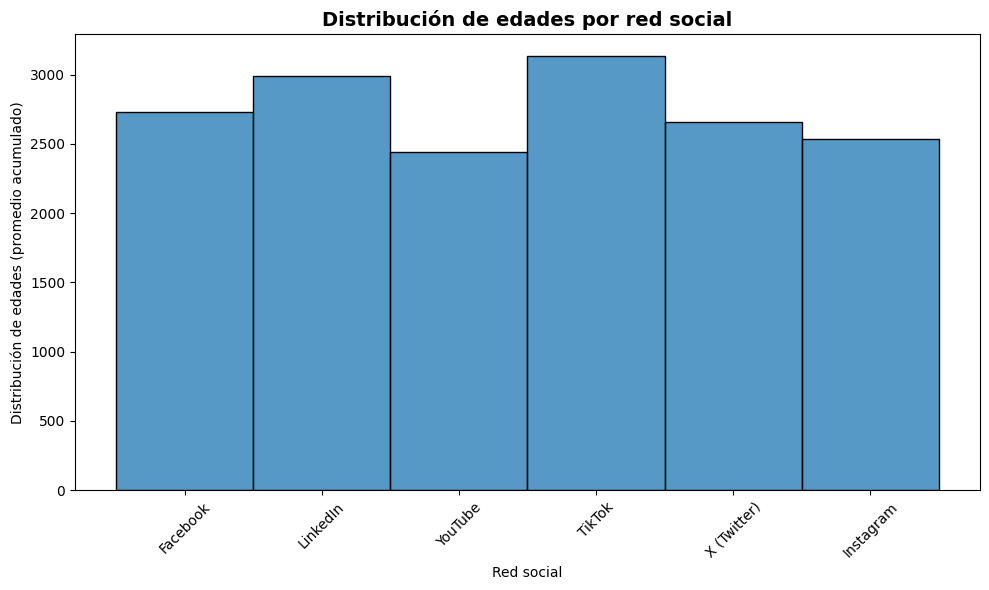

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(data=MiAnalisis, x='social_media_platform', weights='age', multiple='stack', palette='viridis')
plt.title("Distribución de edades por red social", fontsize=14, fontweight='bold')
plt.xlabel("Red social")
plt.ylabel("Distribución de edades (promedio acumulado)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Diagrama de Cajas**

**Boxplot: Edad por Red Social y Género**

In [ ]:
df_melted = MiAnalisis.melt(
    id_vars=['social_media_platform', 'gender'],
    value_vars=['age'],
    var_name='Variable',
    value_name='Valor'
)
# Crear el boxplot interactivo
fig = px.box(
    df_melted,
    x='social_media_platform',
    y='Valor',
    color='gender',
    title='Distribución de la Edad por Red Social y Género',
    points='all')

fig.update_layout(
    xaxis_title='Red Social',
    yaxis_title='Edad',
    template='plotly_white'
)
fig.show()

**Violinplot: Tiempo en Pantalla por Red Social**

/tmp/ipython-input-841900194.py:2: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




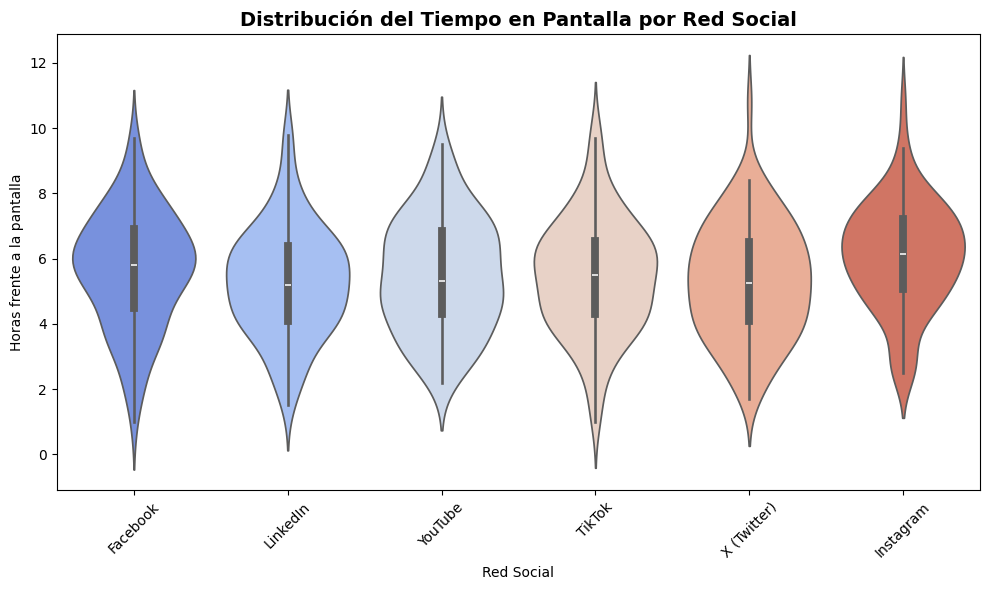

In [ ]:
plt.figure(figsize=(10,6))
sns.violinplot(data=MiAnalisis, x='social_media_platform', y='daily_screen_timehrs', palette='coolwarm')
plt.title("Distribución del Tiempo en Pantalla por Red Social", fontsize=14, fontweight='bold')
plt.xlabel("Red Social")
plt.ylabel("Horas frente a la pantalla")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Diagrama de barras**

**Diagrama de barras: Género y Red Social**

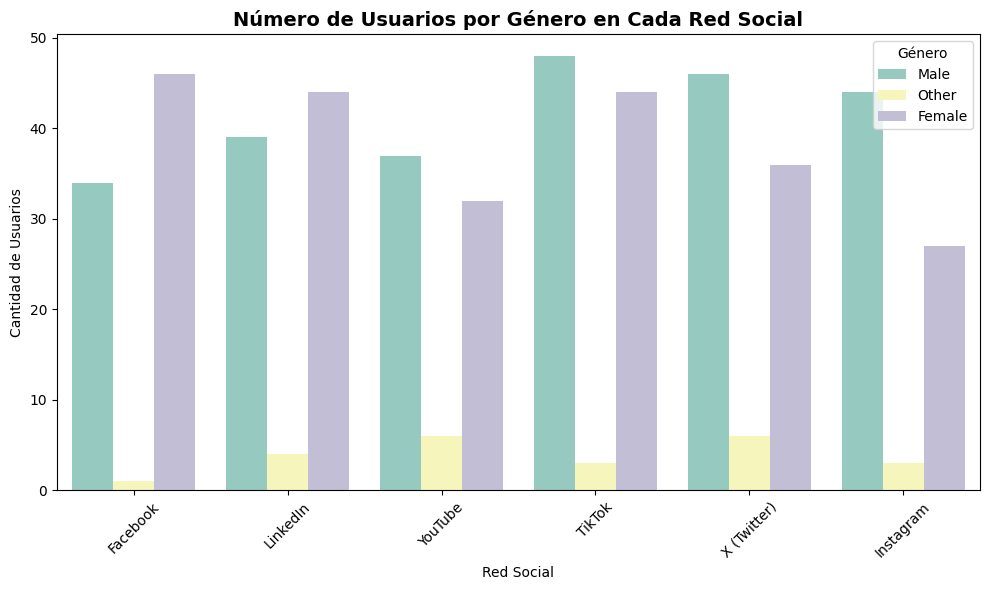

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(data=MiAnalisis, x='social_media_platform', hue='gender', palette='Set3')
plt.title("Número de Usuarios por Género en Cada Red Social", fontsize=14, fontweight='bold')
plt.xlabel("Red Social")
plt.ylabel("Cantidad de Usuarios")
plt.xticks(rotation=45)
plt.legend(title="Género")
plt.tight_layout()
plt.show()


**Joinplot() Redes Sociales**

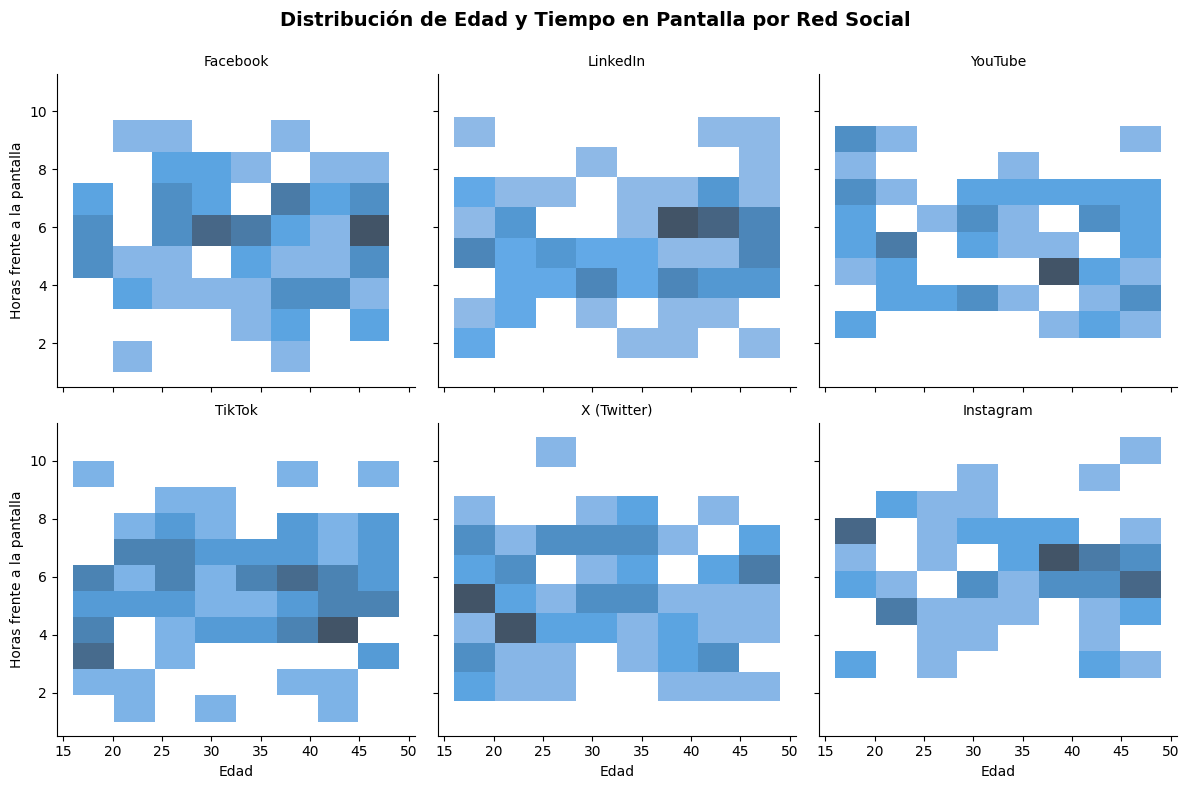

In [ ]:
g = sns.FacetGrid(MiAnalisis, col='social_media_platform', col_wrap=3, height=4)
g.map_dataframe(sns.histplot, x='age', y='daily_screen_timehrs', color='steelblue')
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Edad", "Horas frente a la pantalla")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribución de Edad y Tiempo en Pantalla por Red Social", fontsize=14, fontweight='bold')
plt.show()

**Kdeplot() por redes en base la edad y el tiempo en la pantalla**

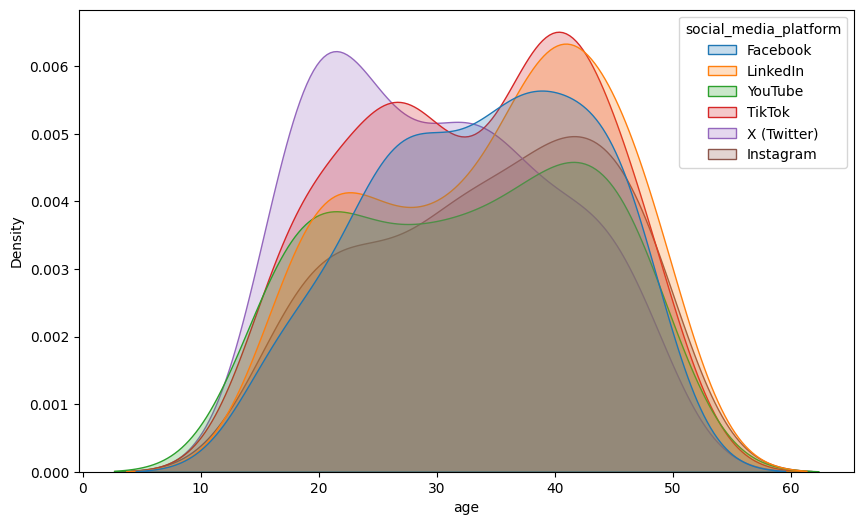

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(MiAnalisis,
             x='age',
             hue='social_media_platform',
             fill=True)
plt.show()

**Heat map**

**Analisis Correlación Spearman Facebook**

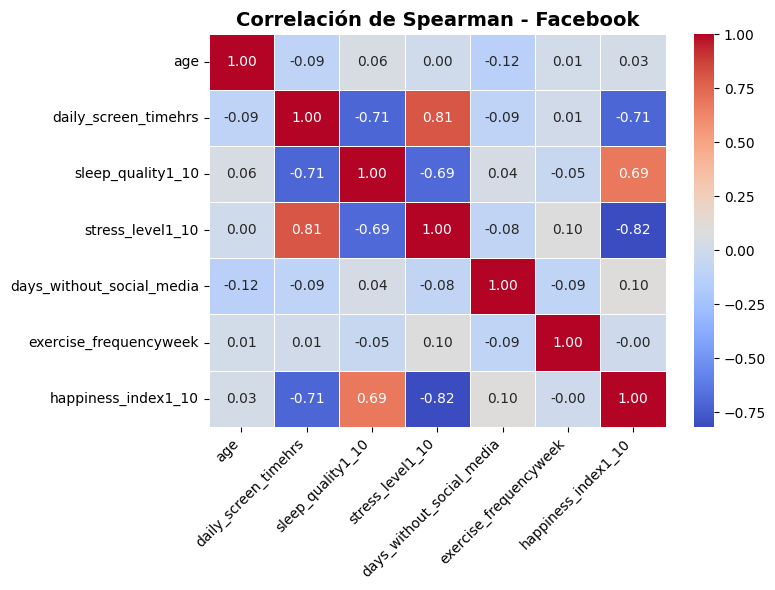

In [ ]:
datos_facebook = MiAnalisis[MiAnalisis['social_media_platform'] == 'Facebook']
datos_num = datos_facebook.select_dtypes(include='number')
corr_facebook = datos_num.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_facebook, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de Spearman - Facebook", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Analisis de correlación(Pearson) en Facebook**

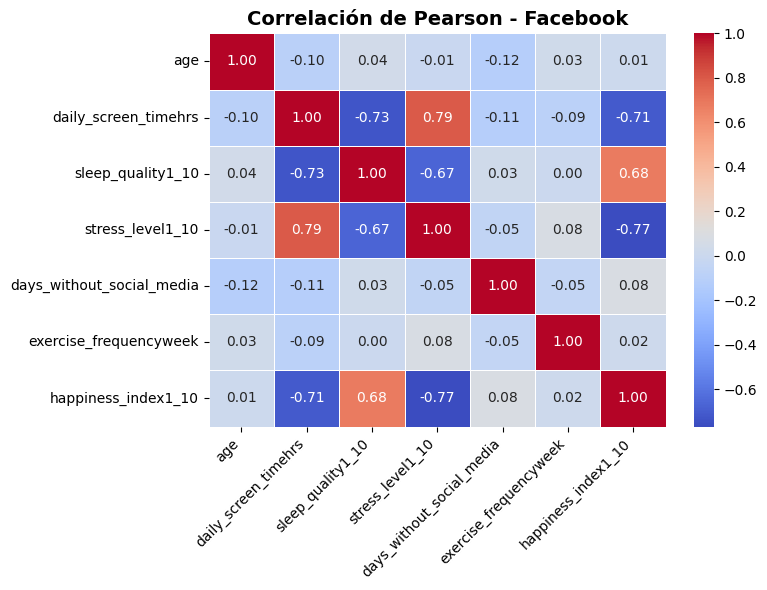

In [ ]:
datos_facebook = MiAnalisis[MiAnalisis['social_media_platform'] == 'Facebook']
datos_num = datos_facebook.select_dtypes(include='number')
corr_facebook = datos_num.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_facebook, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de Pearson - Facebook", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Instagram**

**Pearson**

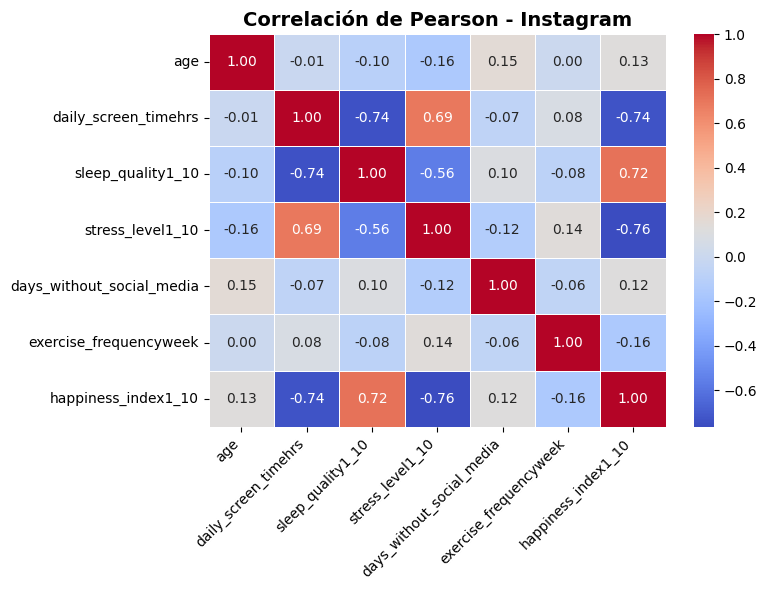

In [ ]:
datos_insta = MiAnalisis[MiAnalisis['social_media_platform'] == 'Instagram']
datos_num = datos_insta.select_dtypes(include='number')
corr_insta = datos_num.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_insta, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de Pearson - Instagram", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Spearman**

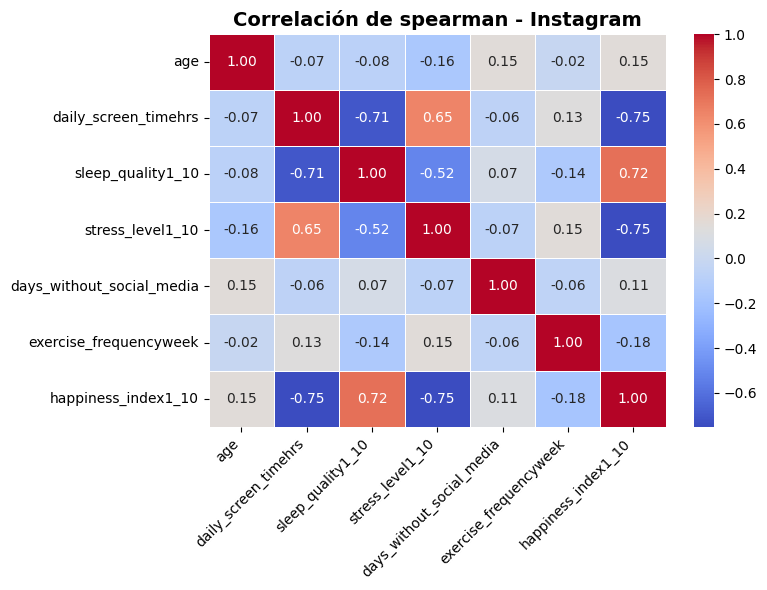

In [ ]:
datos_insta = MiAnalisis[MiAnalisis['social_media_platform'] == 'Instagram']
datos_num = datos_insta.select_dtypes(include='number')
corr_insta = datos_num.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_insta, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de spearman - Instagram", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Twitter (X)**

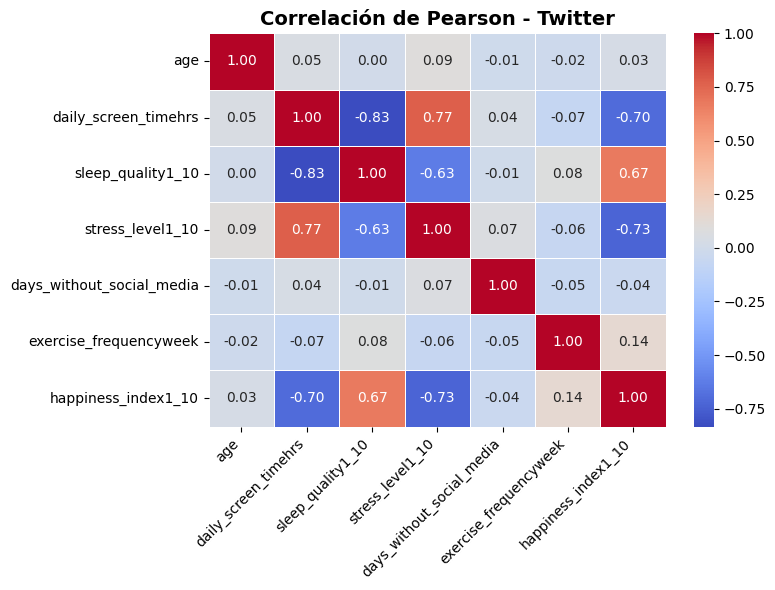

In [ ]:

datos_twitter = MiAnalisis[MiAnalisis['social_media_platform'] == 'X (Twitter)']
datos_num = datos_twitter.select_dtypes(include='number')
corr_twitter = datos_num.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_twitter, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de Pearson - Twitter", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Spearman**

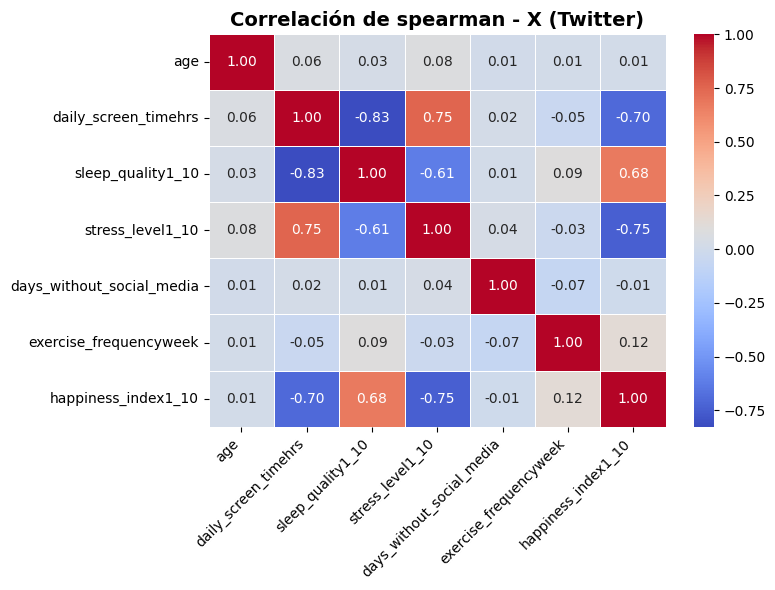

In [ ]:
datos_insta = MiAnalisis[MiAnalisis['social_media_platform'] == 'X (Twitter)']
datos_num = datos_insta.select_dtypes(include='number')
corr_insta = datos_num.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_insta, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de spearman - X (Twitter)", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Linkedin**

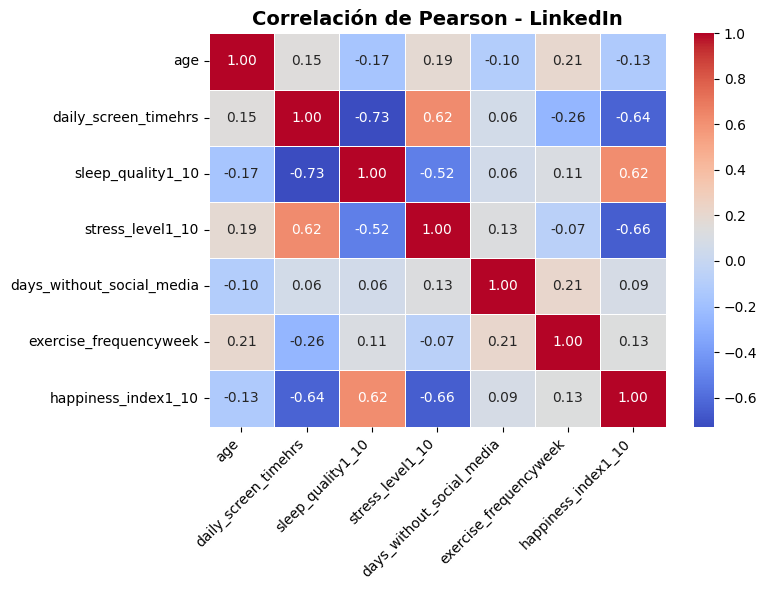

In [ ]:
datos_twitter = MiAnalisis[MiAnalisis['social_media_platform'] == 'LinkedIn']
datos_num = datos_twitter.select_dtypes(include='number')
corr_twitter = datos_num.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_twitter, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de Pearson - LinkedIn", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Spearman**

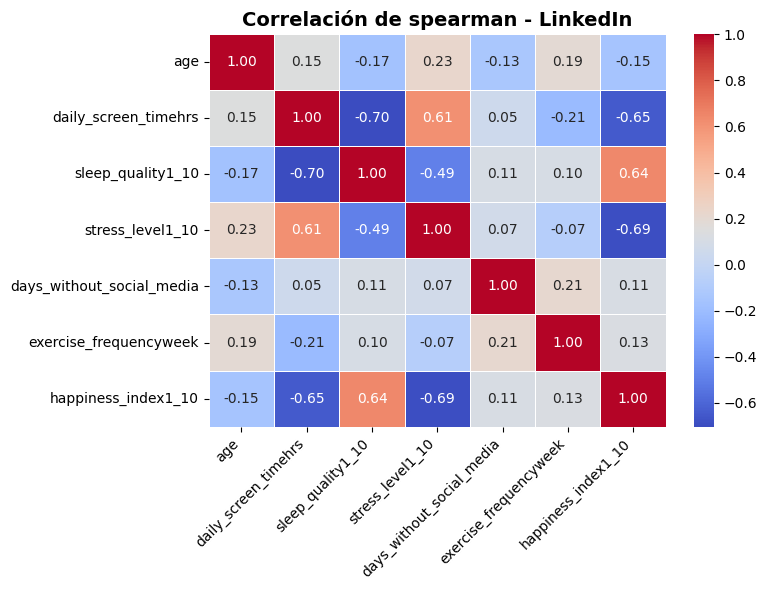

In [ ]:
datos_insta = MiAnalisis[MiAnalisis['social_media_platform'] == 'LinkedIn']
datos_num = datos_insta.select_dtypes(include='number')
corr_insta = datos_num.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_insta, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de spearman - LinkedIn", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Youtube**

**Pearson**

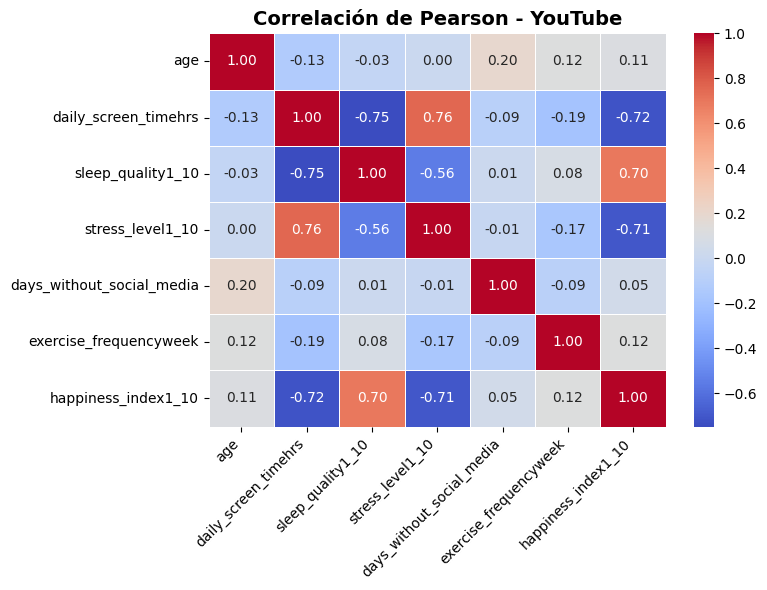

In [ ]:

datos_twitter = MiAnalisis[MiAnalisis['social_media_platform'] == 'YouTube']
datos_num = datos_twitter.select_dtypes(include='number')
corr_twitter = datos_num.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_twitter, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de Pearson - YouTube", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


**Spearman**

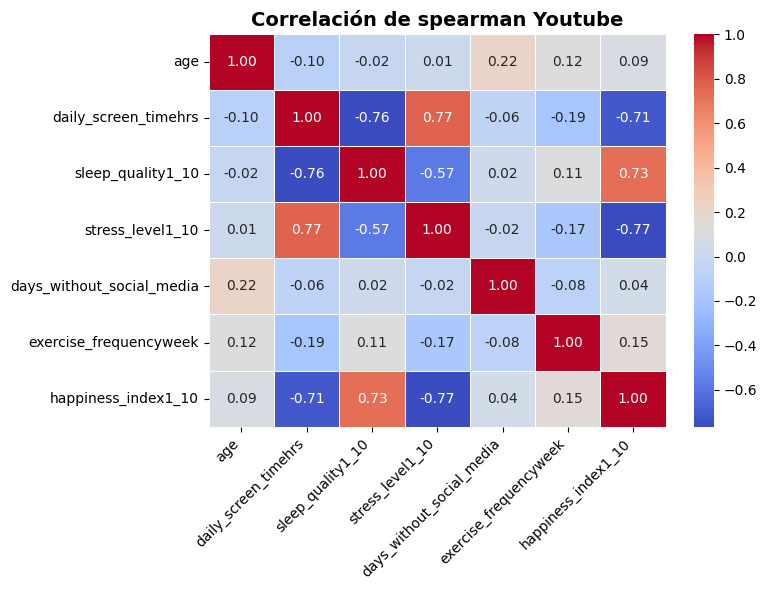

In [ ]:
datos_insta = MiAnalisis[MiAnalisis['social_media_platform'] == 'YouTube']
datos_num = datos_insta.select_dtypes(include='number')
corr_insta = datos_num.corr(method='spearman')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_insta, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de spearman Youtube", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

La matriz de correlación muestra una relación negativa entre la felicidad y el tiempo en pantalla, y una relación positiva entre tiempo en pantalla y estrés. La calidad del sueño también presenta una correlación inversa con el estrés, lo que confirma la conexión entre estos factores de bienestar.

In [ ]:
Correlaciones = {'Tiempo pantalla vs Calidad sueño': Tiempo_Sueño,
                 'Tiempo pantalla vs Nivel estrés': Tiempo_Estres,
                 'Tiempo pantalla vs Felicidad/bienestar': Tiempo_Felicidad}

df_corr = pd.DataFrame((Correlaciones.items()), columns=['Relación', 'Coeficiente de correlación'])
df_corr

,Relación,Coeficiente de correlación
0,Tiempo pantalla vs Calidad sueño,-0.758910
1,Tiempo pantalla vs Nivel estrés,0.739891
2,Tiempo pantalla vs Felicidad/bienestar,-0.705206


Analisis de las 3 variables de salud mental

El análisis realizado evidencia una relación significativa entre el tiempo de exposición a pantallas y distintos indicadores de salud mental. Los resultados muestran una correlación negativa fuerte entre el tiempo de pantalla y la calidad del sueño (r = -0.76), lo que indica que a mayor uso diario de dispositivos, peor es la calidad del descanso. De igual forma, se encontró una correlación positiva notable con el nivel de estrés (r = 0.74), reflejando que el uso prolongado de pantallas incrementa las sensaciones de tensión o sobrecarga emocional. Por último, la relación negativa con el índice de felicidad (r = -0.71) sugiere que el bienestar subjetivo disminuye cuando el uso de redes sociales y dispositivos digitales se vuelve excesivo.

En conjunto, estos hallazgos confirman las hipótesis planteadas: el tiempo frente a pantallas afecta de manera directa la salud mental, deteriorando el sueño y la felicidad, e incrementando el estrés. Sin embargo, este efecto no es completamente lineal; un uso moderado y con propósito positivo (como la comunicación social o el aprendizaje) puede no generar impactos negativos significativos, mientras que un uso excesivo o pasivo tiende a provocar consecuencias adversas más marcadas.

In [ ]:
import warnings
warnings.filterwarnings("ignore")

MiAnalisis['tiempo_uso_hrs'] = pd.cut(MiAnalisis['daily_screen_timehrs'],
                            bins=[0, 3, 6, 10],
                            labels=['Uso moderado (<3h)', 'Uso alto (3–6h)', 'Uso excesivo (>6h)'])

# Promedios por grupo

resumen = MiAnalisis.groupby('tiempo_uso_hrs')[['sleep_quality1_10', 'stress_level1_10', 'happiness_index1_10']].mean()
resumen

,sleep_quality1_10,stress_level1_10,happiness_index1_10
tiempo_uso_hrs,,,
Uso moderado (<3h),8.375000,4.350000,9.825000
Uso alto (3–6h),6.867188,6.058594,9.042969
Uso excesivo (>6h),5.207921,7.747525,7.282178


**Conclusión: Objetivo**

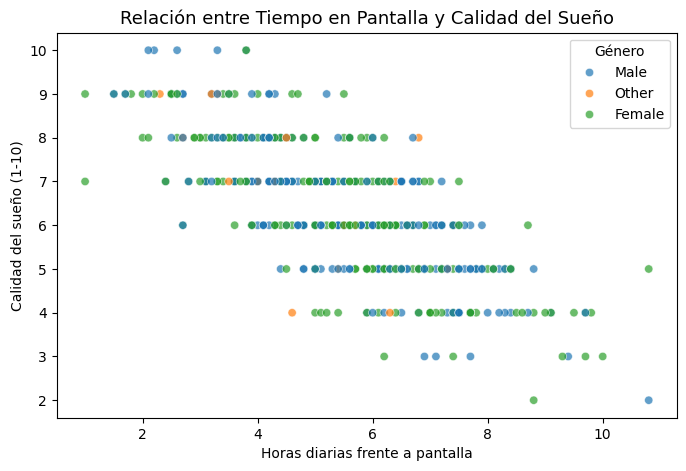

In [ ]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=MiAnalisis,
    x="daily_screen_timehrs",
    y="sleep_quality1_10",
    hue="gender",
    alpha=0.7
)
plt.title("Relación entre Tiempo en Pantalla y Calidad del Sueño", fontsize=13)
plt.xlabel("Horas diarias frente a pantalla")
plt.ylabel("Calidad del sueño (1-10)")
plt.legend(title="Género")
plt.show()

**Promedio de indicadores de habitos (dias sin redes sociales, frecuencia del ejercicio, índice de felicidad y calidad del sueño)**

Ejecutar renombrado de columnas y valores de col "Gender"

In [ ]:
print('El promedio de dias sin redes sociales es:', Mi_Analisis['Dias sin redes sociales'].mean(),'dias.')
print('El promedio del nivel de estres en escala del 1 a 10 es:', Mi_Analisis['Nivel de estres(1-10)'].mean())
print('El promedio de la calidad del sueño en escala del 1 a 10 es:', Mi_Analisis['Calidad del sueño(1-10)'].mean())
print('El promedio del indice de felicidad/bienestar en escala del 1 al 10 es:', Mi_Analisis['Indice de felicidad/bienestar(1-10)'].mean())
print('El promedio de la freccuencia de ejercicio a la semana es:',Mi_Analisis['Frecuencia de ejercicio(semanal)'].mean(),'dias por semana.')

El promedio de dias sin redes sociales es: 3.134 dias.
El promedio del nivel de estres en escala del 1 a 10 es: 6.618
El promedio de la calidad del sueño en escala del 1 a 10 es: 6.304
El promedio del indice de felicidad/bienestar en escala del 1 al 10 es: 8.376
El promedio de la freccuencia de ejercicio a la semana es: 2.448 dias por semana.


In [ ]:
print('El maximo de dias sin redes sociales es:', Mi_Analisis['Dias sin redes sociales'].max(),'dias.')
print('El minimo de dias sin redes sociales es:', Mi_Analisis['Dias sin redes sociales'].min(),'dias.')

El maximo de dias sin redes sociales es: 9.0 dias.
El minimo de dias sin redes sociales es: 0.0 dias.


In [ ]:
Felicidad_Sueno= Mi_Analisis.groupby('Calidad del sueño(1-10)')['Indice de felicidad/bienestar(1-10)'].count().sort_values(ascending=False)
Felicidad_Sueno
#Felicidad por calidad del sueño

,happiness_index1-10
sleep_quality1-10,
6.0,120
7.0,116
5.0,93
8.0,67
4.0,51
9.0,36
3.0,9
10.0,6
2.0,2


/tmp/ipython-input-1379009316.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


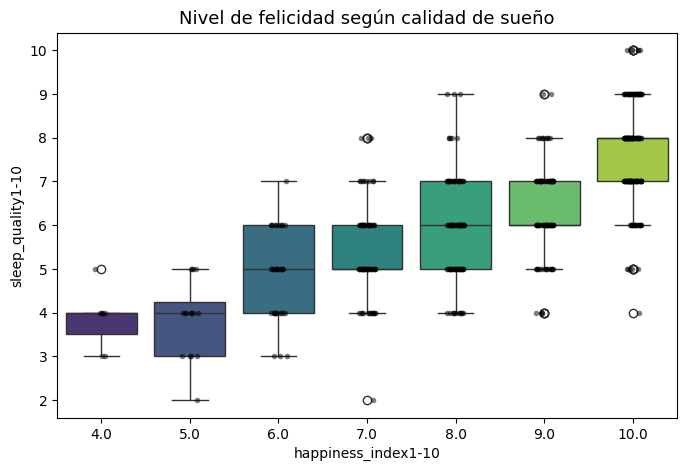

Correlación entre sueño y felicidad: 0.68


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=Mi_Analisis,
    x='Indice de felicidad/bienestar(1-10)',
    y='Calidad del sueño(1-10)',
    palette="viridis"
)
sns.stripplot(
    data=Mi_Analisis,
    x='Indice de felicidad/bienestar(1-10)',
    y='Calidad del sueño(1-10)',
    color="black",
    size=4,
    alpha=0.5
)
plt.title("Nivel de felicidad según calidad de sueño", fontsize=13)
plt.xlabel('Indice de felicidad/bienestar(1-10)')
plt.ylabel('Calidad del sueño(1-10)')
plt.show()

corr = Mi_Analisis['Calidad del sueño(1-10)'].corr(Mi_Analisis['Indice de felicidad/bienestar(1-10)'])
print(f"Correlación entre sueño y felicidad: {corr:.2f}")

Con una Correlación 0, 68 entre la calidad del sueño y el índice de felicidad indicada una relación positiva moderada , es decir a mayor calidad de sueño, mayor nivel de felicidad.

In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=Mi_Analisis,
    x='Indice de felicidad/bienestar(1-10)',
    y='Frecuencia de ejercicio(semanal)',
    palette="viridis"
)
sns.stripplot(
    data=Mi_Analisis,
    x='Indice de felicidad/bienestar(1-10)',
    y='Frecuencia de ejercicio(semanal)',
    color="black",
    size=4,
    alpha=0.5
)
plt.title("Nivel de felicidad según frecuencia de ejercicio", fontsize=13)
plt.xlabel('Indice de felicidad/bienestar(1-10)')
plt.ylabel('Frecuencia de ejercicio(semanal)')
plt.show()

corr = Mi_Analisis['Frecuencia de ejercicio(semanal)'].corr(Mi_Analisis['Indice de felicidad/bienestar(1-10)'])
print(f"Correlación entre ejercicio y felicidad: {corr:.2f}")

Con una correlación de 0.04 es prácticamente nula, lo que implica que no hay una relación lineal entre las 2 variables, es decir, hacer más ejercicio no garantiza sentirse más feliz.

Correlación de Pearson exclusiva para usuarios de Facebook

In [ ]:
datos_facebook = Mi_Analisis[Mi_Analisis['Plataforma digital'] == 'Facebook']
datos_num = datos_facebook.select_dtypes(include='number')
corr_facebook = datos_num.corr(method='pearson')

plt.figure(figsize=(8, 6))
sns.heatmap(corr_facebook, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title("Correlación de Pearson", fontsize=14, fontweight='bold')
plt.show()

En la correlación de pearson es posible observar que la felicidad o bienestar de las personas se encuentra linealmente relacionado con la calidad del sueño con un índice de correlación de 0.68, y es inversamente proporcional con el nivel de estrés siendo este de - 0.77; además, al observar los índices de correlación de las demás variables como la frecuencia de ejercicio semanal y los días sin redes sociales presentan una correlación muy débil con respecto al índice de felicidad y bienestar, lo que nos indica una relación casi nula entre las variables.

**Nivel de Felicidad y Estres**

In [ ]:
#Mediana del nivel del indice de felicidad
Mediana_Felicidad = Mi_Analisis['Indice de felicidad/bienestar(1-10)'].median()
#Mediana del nivel de estres
Mediana_Estres = Mi_Analisis['Nivel de estres(1-10)'].median()

#Moda de Nivel de felicidad
Moda_Felicidad = Mi_Analisis['Indice de felicidad/bienestar(1-10)'].mode()
#Moda de Nivel de estres
Moda_Estres = Mi_Analisis['Nivel de estres(1-10)'].mode()



df_Moda_Mediana = pd.DataFrame({
                                'Mediana': [Mediana_Felicidad, Mediana_Estres],
                                'Moda': [Moda_Felicidad[0], Moda_Estres[0]]},
                                index=['Indice de felicidad/bienestar(1-10)', 'Nivel de estres(1-10)'])
df_Moda_Mediana

Se puede identificar que la muestra presenta un alto índice de felicidad, sin embargo también es relevante el nivel de estrés que se presenta entre las personas de la muestra.

In [ ]:
std = Mi_Analisis.groupby('Nivel de estres(1-10)')['Indice de felicidad/bienestar(1-10)'].std()
std
std.skew()

La variabilidad del Índice de felicidad/bienestar aumenta a medida que sube el nivel de estrés. En niveles bajos de estrés, la felicidad es más estable con desviaciones estándar pequeñas o nulas, mientras que en niveles altos de estrés la felicidad se dispersa mucho más; esto indica que las personas con mayor estrés presentan niveles de felicidad más impredecibles, lo que sugiere que el estrés no solo reduce el bienestar, sino que lo vuelve menos consistente entre las personas de la muestra.

**Graficos**

Pairplot

In [ ]:
sns.pairplot(Mi_Analisis)
plt.show()

Pairplot por redes

In [ ]:
sns.pairplot(Mi_Analisis)
plt.show()

**Histograma  felicidad / estres**

In [ ]:
plt.figure(figsize=(10, 8))
sns.histplot(
    data=Mi_Analisis,
    x='Indice de felicidad/bienestar(1-10)',
    weights=Mi_Analisis['Nivel de estres(1-10)'],
    kde=False
)
plt.title('Histograma Felicidad Ponderado por Nivel de Estrés', fontsize=14, fontweight='bold')
plt.xlabel('Nivel de Felicidad')
plt.ylabel('Nivel de estres')
plt.tight_layout()
plt.show()

El histograma muestra que los niveles de felicidad más altos (aproximadamente entre 7 y 10) concentran una cantidad importante de personas con niveles variados de estrés, pero predominan los niveles de estrés medios y altos. A medida que la felicidad disminuye, también disminuye la presencia de personas en casi todos los niveles de estrés, lo que sugiere que la mayoría de los participantes mantienen niveles de felicidad relativamente altos incluso en presencia de estrés. Esto indica que, dentro de la muestra, el estrés no reduce de forma drástica el nivel de felicidad, aunque sí se observa una mayor variabilidad en los niveles de estrés dentro de los rangos de felicidad más altos.

**Joinplot() Redes Sociales**

In [ ]:
g = sns.FacetGrid(Mi_Analisis, col='Social_Media_Platform', col_wrap=3, height=4)
g.map_dataframe(sns.histplot, x='Age', y='Daily_Screen_Time(hrs)', color='steelblue')
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Edad", "Horas frente a la pantalla")
plt.subplots_adjust(top=0.9)
g.fig.suptitle("Distribución de Edad y Tiempo en Pantalla por Red Social", fontsize=14, fontweight='bold')
plt.show()

**Kdeplot() por redes en base la edad y el tiempo en la pantalla**

In [ ]:
sns.kdeplot(Mi_Analisis,
             x='Nivel de estres(1-10)',
             y='Frecuencia de ejercicio(semanal)',
             cmap='mako',
             fill=True)
plt.show()

La distribución conjunta muestra que la mayor concentración de personas se encuentra en niveles moderados de estrés y con una frecuencia de ejercicio baja o media. La densidad disminuye notablemente en las zonas donde la frecuencia de ejercicio es alta, lo que sugiere que son menos comunes las personas que realizan ejercicio frecuente, independientemente de su nivel de estrés.

Además, no se observa una relación clara y lineal entre ambas variables; sin embargo, la forma de la densidad indica que las personas con niveles más altos de ejercicio tienden a concentrarse ligeramente hacia niveles de estrés moderadamente bajos, lo que podría sugerir un efecto beneficioso del ejercicio sobre la reducción del estrés.

**Comparar las diferencias en los indicadores de salud mental según la plataforma**

In [ ]:
conteo = MiAnalisis["social_media_platform"].value_counts(sort=False).reset_index()
conteo.columns = ["Plataforma", "Número de usuarios"]

fig = px.bar(
    conteo,
    x="Plataforma",
    y="Número de usuarios",
    color="Plataforma",
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title="Distribución de uso por plataforma de redes sociales",
    text="Número de usuarios"  # Esto pone las etiquetas encima de la barra
)

fig.update_layout(
    xaxis_title="Plataforma de red social",
    yaxis_title="Número de participantes",
    xaxis_tickangle=30,
    showlegend=False
)

fig.update_traces(textposition="outside")

fig.show()


NameError: name 'MiAnalisis' is not defined

In [ ]:
def slepp_cuality():
  fig = px.box(
    MiAnalisis,
    x="social_media_platform",
    y="sleep_quality1_10",
    color="social_media_platform",
    color_discrete_sequence=px.colors.qualitative.Pastel,
    title="Calidad del sueño según plataforma de red social",
    points="all")
  fig.update_layout(
    xaxis_title="Plataforma",
    yaxis_title="Calidad del sueño (1-10)",
    xaxis_tickangle=30)
  return fig.show()
def estress_level():
  fig = px.box(
    MiAnalisis,
    x="social_media_platform",
    y="stress_level1_10",
    color="social_media_platform",
    color_discrete_sequence=px.colors.qualitative.Safe,
    title="Nivel de estrés según plataforma de red social",
    points="all")
  fig.update_layout(
    xaxis_title="Plataforma",
    yaxis_title="Nivel de estrés (1-10)",
    xaxis_tickangle=30)
  return fig.show()
def happines_level():
  fig = px.box(
    MiAnalisis,
    x="social_media_platform",
    y="happiness_index1_10",
    color="social_media_platform",
    color_discrete_sequence=px.colors.qualitative.Set2,
    title="Índice de felicidad según plataforma de red social",
    points="all")
  fig.update_layout(
    xaxis_title="Plataforma",
    yaxis_title="Felicidad (1-10)",
    xaxis_tickangle=30)
  return fig.show()
#slepp_cuality()
#estress_level()
#happines_level()

**Conclusión Final**

El análisis sugiere que el uso intensivo de plataformas con alto estímulo visual y emocional (TikTok, Instagram) se asocia con mayor estrés y peor calidad de sueño, mientras que plataformas de consumo más moderado o profesional (LinkedIn, YouTube) tienden a favorecer un mejor equilibrio emocional.

En resumen: el tiempo de pantalla influye directamente en la salud mental, pero la naturaleza del contenido y la dinámica social de cada plataforma amplifican o moderan ese efecto.

**Patrones y correlaciones**

* A mayor tiempo de pantalla (según plataformas más adictivas como TikTok e
Instagram), menor calidad de sueño y mayor nivel de estrés.

* La felicidad no siempre disminuye con mayor uso, sino que depende del tipo de contenido y la interacción.
Ejemplo: LinkedIn y YouTube mantienen felicidad alta pese al uso frecuente, probablemente por fines más productivos o de entretenimiento relajado.

* Dispersión amplia = vulnerabilidad emocional. TikTok e Instagram muestran alta variabilidad entre usuarios, lo que sugiere que el impacto psicológico depende mucho del perfil y hábitos individuales.

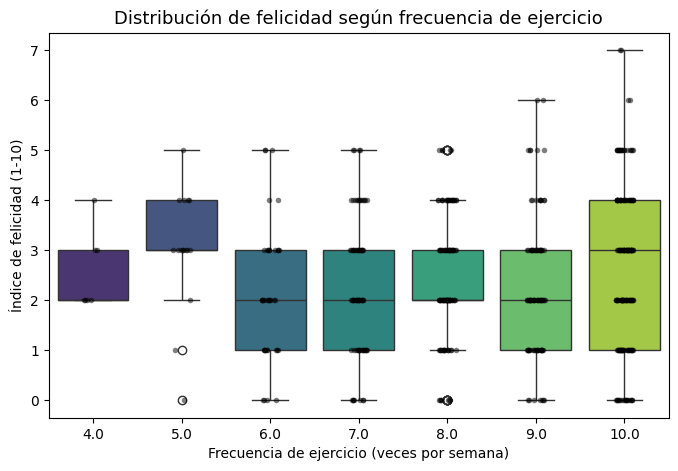

Correlación entre ejercicio y felicidad: 0.04


In [ ]:
plt.figure(figsize=(8,5))
sns.boxplot(
    data=MiAnalisis,
    x="happiness_index1_10",
    y="exercise_frequencyweek",
    palette="viridis"
)
sns.stripplot(
    data=MiAnalisis,
    x="happiness_index1_10",
    y="exercise_frequencyweek",
    color="black",
    size=4,
    alpha=0.5
)
plt.title("Distribución de felicidad según frecuencia de ejercicio", fontsize=13)
plt.xlabel("Frecuencia de ejercicio (veces por semana)")
plt.ylabel("Índice de felicidad (1-10)")
plt.show()

corr = MiAnalisis["exercise_frequencyweek"].corr(MiAnalisis["happiness_index1_10"])
print(f"Correlación entre ejercicio y felicidad: {corr:.2f}")

**Columnas a español**

In [ ]:
# Mi_Analisis = Mi_Analisis.rename(columns={'User_ID': 'ID',
#                                           'Age': 'Edad',
#                                           'Gender': 'Genero',
#                                           'Daily_Screen_Time(hrs)': 'Tiempo en pantalla(hrs)',
#                                           'Sleep_Quality(1-10)': 'Calidad del sueño(1-10)',
#                                           'Stress_Level(1-10)': 'Nivel de estres(1-10)',
#                                           'Days_Without_Social_Media': 'Dias sin redes sociales',
#                                           'Exercise_Frequency(week)': 'Frecuencia de ejercicio(semanal)',
#                                           'Social_Media_Platform': 'Plataforma digital',
#                                           'Happiness_Index(1-10)': 'Indice de felicidad/bienestar(1-10)'})
# Mi_Analisis

**Conclusiones generales**
* TikTok y X (Twitter) presentan tendencias más marcadas de estrés elevado y menor calidad de sueño.

* En TikTok, la concentración de usuarios en valores de sueño entre 5 y 7 indica ligero deterioro del descanso.

* X (Twitter) muestra amplia dispersión en estrés, con varios usuarios en el rango alto (8–10).

* Esto podría asociarse al tipo de contenido más emocional o polarizante presente en esas plataformas.

* LinkedIn y Facebook tienden a tener mejor balance emocional, especialmente en felicidad y calidad de sueño.

* LinkedIn destaca con una mediana de felicidad más alta (9–10) y una dispersión reducida.

* Facebook mantiene valores medios de felicidad y menor estrés comparado con TikTok e Instagram.

* YouTube aparece como la plataforma más estable emocionalmente.

* Los tres indicadores (sueño, estrés y felicidad) presentan distribuciones equilibradas, sin grandes extremos.

* Es coherente con un consumo más pasivo y menos interactivo, lo cual genera menor sobrecarga emocional.

* Instagram se ubica en un punto medio–alto de estrés, con dispersión amplia en felicidad.

* Muestra el clásico patrón de comparación social, donde algunos usuarios reportan felicidad alta (por dopamina visual) y otros baja (por frustración o comparación).